# HW2: Квантизация через bitsandbytes

Я взял модель из `hw1` — `Harsha901/tinybert-imdb-sentiment-analysis-model` — и сравнил обычную версию с квантизованной.

Запускал на Apple M4 Pro, но в CPU-режиме. MPS не использовал, потому что у `bitsandbytes` на Apple Silicon поддержка пока не очень стабильная, и такой запуск может работать медленнее обычного CPU.


## Модель и метод

- Модель: `Harsha901/tinybert-imdb-sentiment-analysis-model`.
- Задача: binary sentiment classification на IMDb.
- В `hw1` было видно, что основная нагрузка идет на линейные слои в attention и feed-forward части.

Я выбрал квантизацию не только из-за bottlenecks из `hw1`, но и потому что раньше с ней нормально не работал и мне было интересно попробовать этот подход на практике.

Поэтому здесь я использую post-training quantization через `bitsandbytes`. Идея простая: уменьшить точность весов без дообучения и посмотреть, что получится по памяти, размеру модели и скорости. При этом качество может немного просесть.


In [1]:
import io
import os
import random
import statistics
import time

import bitsandbytes as bnb
import matplotlib.pyplot as plt
import pandas as pd
import torch
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, BitsAndBytesConfig

/Users/soundwave77/projects/distillation_course/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)


class EncodedTextDataset(Dataset):
    def __init__(self, encodings: dict[str, torch.Tensor], labels: torch.Tensor):
        self.encodings = encodings
        self.labels = labels

    def __len__(self) -> int:
        return self.labels.shape[0]

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item


def binary_f1(preds: torch.Tensor, labels: torch.Tensor) -> float:
    tp = ((preds == 1) & (labels == 1)).sum().item()
    fp = ((preds == 1) & (labels == 0)).sum().item()
    fn = ((preds == 0) & (labels == 1)).sum().item()

    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    return 2 * precision * recall / (precision + recall)


def safe_state_size_mb(model) -> float:
    try:
        buffer = io.BytesIO()
        torch.save(model.state_dict(), buffer)
        return len(buffer.getvalue()) / (1024 ** 2)
    except Exception:
        return float("nan")


In [3]:
cfg = {
    "model_name": "Harsha901/tinybert-imdb-sentiment-analysis-model",
    "seed": 42,
    "test_samples": 500,
    "max_length": 256,
    "batch_size": 16,
    "warmup_batches": 8,
    "num_threads": min(8, os.cpu_count() or 8),
    "device": "cpu",
    "quant_modes": ["8bit", "4bit"],
    "baseline_dtype": "float32",
}

set_seed(cfg["seed"])
torch.set_num_threads(cfg["num_threads"])
device = cfg["device"]

## Эксперимент

Схема простая: сначала загружаю baseline в `float32`, потом ту же модель в `8bit` и `4bit` через `BitsAndBytesConfig`, после чего сравниваю их на одном и том же куске `IMDb test`.

Чтобы сравнение было честным, везде одинаковые `seed`, `batch_size`, `max_length`, число потоков CPU и warmup перед замером.


## Данные


In [4]:
tokenizer = AutoTokenizer.from_pretrained(cfg["model_name"])

raw_test = load_dataset("imdb", split="test").shuffle(seed=cfg["seed"]).select(range(cfg["test_samples"]))
texts = list(raw_test["text"])
labels = torch.tensor(list(raw_test["label"]), dtype=torch.long)

enc = tokenizer(
    texts,
    truncation=True,
    padding="max_length",
    max_length=cfg["max_length"],
    return_tensors="pt",
)

test_ds = EncodedTextDataset(enc, labels)
test_loader = DataLoader(test_ds, batch_size=cfg["batch_size"], shuffle=False)

print("Prepared samples:", len(test_ds))
print("Input tensor shape:", tuple(enc["input_ids"].shape))


Prepared samples: 500
Input tensor shape: (500, 256)


## Метрики

По качеству смотрю `accuracy` и `F1`. По производительности — `mean/p95 latency` и `throughput`. Отдельно считаю `memory_footprint_mb` и `state_dict_size_mb`, чтобы было видно, есть ли реальный выигрыш по памяти и размеру модели.


## Загрузка моделей


In [5]:
def get_dtype(name: str):
    if name == "float32":
        return torch.float32
    if name == "float16":
        return torch.float16


def build_bnb_config(quant_mode: str) -> BitsAndBytesConfig:
    if quant_mode == "8bit":
        return BitsAndBytesConfig(load_in_8bit=True)

    if quant_mode == "4bit":
        return BitsAndBytesConfig(
            load_in_4bit=True,
        )

    raise ValueError("quant_mode должен быть 8bit или 4bit")


baseline_dtype = get_dtype(cfg["baseline_dtype"])

model_baseline = AutoModelForSequenceClassification.from_pretrained(
    cfg["model_name"],
    dtype=baseline_dtype,
    device_map="cpu",
).eval()

quantized_models = {}
for quant_mode in cfg["quant_modes"]:
    quantized_models[quant_mode] = AutoModelForSequenceClassification.from_pretrained(
        cfg["model_name"],
        quantization_config=build_bnb_config(quant_mode),
        device_map="cpu",
    ).eval()

print("Baseline dtype:", cfg["baseline_dtype"])
print("Quant modes:", cfg["quant_modes"])


Loading weights: 100%|██████████| 73/73 [00:00<00:00, 1087.93it/s]

Baseline dtype: float32
Quant modes: ['8bit', '4bit']


## Оценка качества и скорости


In [6]:
@torch.inference_mode()
def evaluate_quality(model, loader: DataLoader) -> dict[str, float]:
    model.eval()
    all_preds = []
    all_labels = []

    for batch in loader:
        inputs = {k: v for k, v in batch.items() if k != "labels"}
        labels = batch["labels"]
        logits = model(**inputs).logits
        preds = logits.argmax(dim=-1)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)

    acc = (preds == labels).float().mean().item()
    f1 = binary_f1(preds, labels)
    return {"accuracy": acc, "f1": f1}


@torch.inference_mode()
def benchmark_inference(model, loader: DataLoader, warmup_batches: int) -> dict[str, float]:
    model.eval()
    latencies_ms = []
    seen_samples = 0

    for i, batch in enumerate(loader):
        inputs = {k: v for k, v in batch.items() if k != "labels"}

        if i < warmup_batches:
            _ = model(**inputs)
            continue

        t0 = time.perf_counter()
        _ = model(**inputs)
        t1 = time.perf_counter()

        latencies_ms.append((t1 - t0) * 1000.0)
        seen_samples += inputs["input_ids"].shape[0]

    mean_ms = statistics.fmean(latencies_ms)
    p50_ms = statistics.median(latencies_ms)
    p95_ms = sorted(latencies_ms)[int(0.95 * (len(latencies_ms) - 1))]
    total_time_s = sum(latencies_ms) / 1000.0
    throughput = seen_samples / total_time_s

    return {
        "mean_batch_latency_ms": mean_ms,
        "p50_batch_latency_ms": p50_ms,
        "p95_batch_latency_ms": p95_ms,
        "throughput_samples_s": throughput,
    }


def collect_metrics(model, loader: DataLoader) -> dict[str, float]:
    q = evaluate_quality(model, loader)
    p = benchmark_inference(model, loader, cfg["warmup_batches"])

    params = sum(p.numel() for p in model.parameters())
    memory_footprint_mb = model.get_memory_footprint() / (1024 ** 2)
    state_size_mb = safe_state_size_mb(model)

    return {
        **q,
        **p,
        "params_million": params / 1e6,
        "memory_footprint_mb": memory_footprint_mb,
        "state_dict_size_mb": state_size_mb,
    }


## Сравнение

Сначала считаю метрики для baseline, потом отдельно для `8bit` и `4bit`, после чего добавляю относительные изменения по сравнению с baseline.


In [7]:
metrics_baseline = collect_metrics(model_baseline, test_loader)

rows = [metrics_baseline]
index = [f"baseline_{cfg['baseline_dtype']}"]

for quant_mode, model in quantized_models.items():
    rows.append(collect_metrics(model, test_loader))
    index.append(f"bnb_{quant_mode}")

comparison = pd.DataFrame(
    rows,
    index=index,
)

base = comparison.iloc[0]
comparison["latency_speedup_vs_baseline"] = base["mean_batch_latency_ms"] / comparison["mean_batch_latency_ms"]
comparison["throughput_gain_vs_baseline"] = comparison["throughput_samples_s"] / base["throughput_samples_s"]
comparison["accuracy_delta_pp_vs_baseline"] = (comparison["accuracy"] - base["accuracy"]) * 100
comparison["memory_reduction_vs_baseline"] = base["memory_footprint_mb"] / comparison["memory_footprint_mb"]
comparison["size_reduction_vs_baseline"] = base["state_dict_size_mb"] / comparison["state_dict_size_mb"]

comparison


/Users/soundwave77/projects/distillation_course/.venv/lib/python3.14/site-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


,accuracy,f1,mean_batch_latency_ms,p50_batch_latency_ms,p95_batch_latency_ms,throughput_samples_s,params_million,memory_footprint_mb,state_dict_size_mb,latency_speedup_vs_baseline,throughput_gain_vs_baseline,accuracy_delta_pp_vs_baseline,memory_reduction_vs_baseline,size_reduction_vs_baseline
baseline_float32,0.886,0.880503,46.231983,46.980229,49.356667,335.265742,14.350874,54.752052,54.770393,1.000000,1.000000,0.000000,1.000000,1.000000
bnb_8bit,0.896,0.892562,238.373931,244.618417,249.414459,65.023889,14.350874,41.446373,41.522832,0.193947,0.193947,1.000005,1.321034,1.319043
bnb_4bit,0.732,0.781759,57.172465,58.422333,59.687375,271.109527,12.025538,39.228760,39.551164,0.808641,0.808641,-15.399998,1.395712,1.384799


In [8]:
report_table = comparison[[
    "accuracy",
    "f1",
    "mean_batch_latency_ms",
    "p95_batch_latency_ms",
    "throughput_samples_s",
    "memory_footprint_mb",
    "state_dict_size_mb",
    "params_million",
    "latency_speedup_vs_baseline",
    "throughput_gain_vs_baseline",
    "memory_reduction_vs_baseline",
    "size_reduction_vs_baseline",
    "accuracy_delta_pp_vs_baseline",
]]

report_table


,accuracy,f1,mean_batch_latency_ms,p95_batch_latency_ms,throughput_samples_s,memory_footprint_mb,state_dict_size_mb,params_million,latency_speedup_vs_baseline,throughput_gain_vs_baseline,memory_reduction_vs_baseline,size_reduction_vs_baseline,accuracy_delta_pp_vs_baseline
baseline_float32,0.886,0.880503,46.231983,49.356667,335.265742,54.752052,54.770393,14.350874,1.000000,1.000000,1.000000,1.000000,0.000000
bnb_8bit,0.896,0.892562,238.373931,249.414459,65.023889,41.446373,41.522832,14.350874,0.193947,0.193947,1.321034,1.319043,1.000005
bnb_4bit,0.732,0.781759,57.172465,59.687375,271.109527,39.228760,39.551164,12.025538,0.808641,0.808641,1.395712,1.384799,-15.399998


## Графики


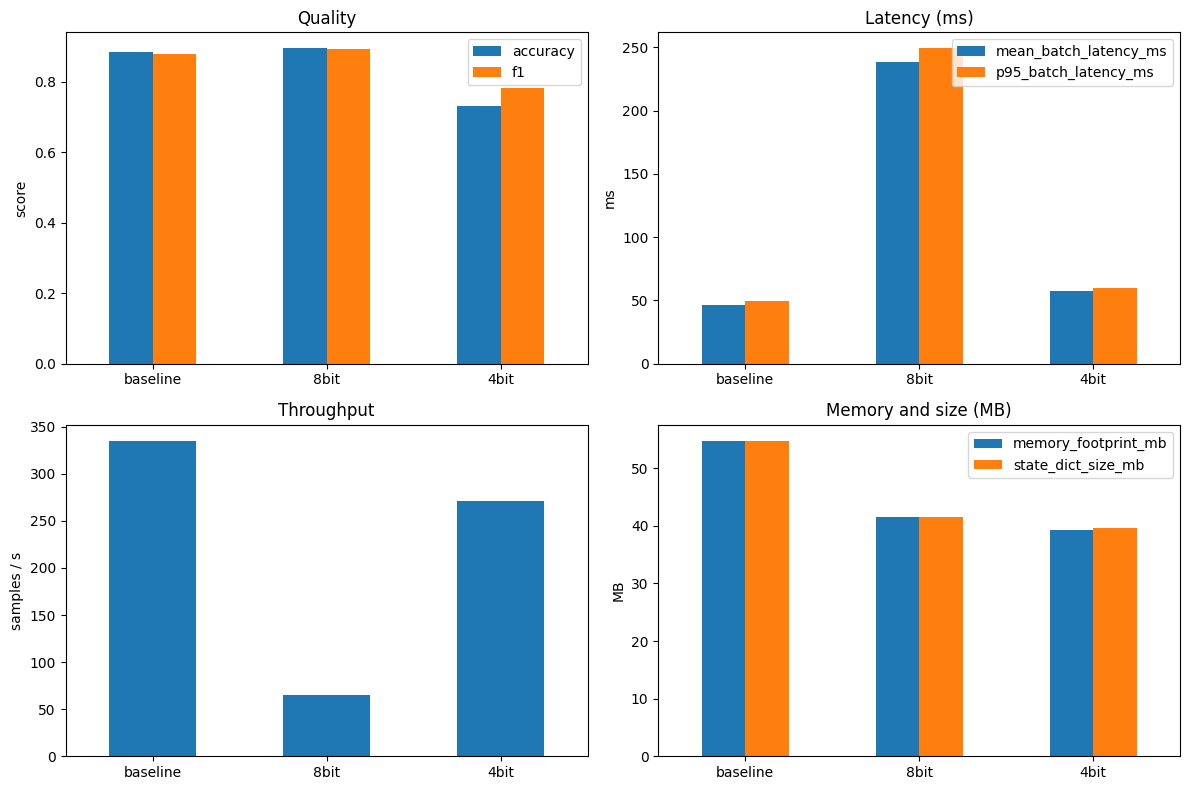

In [9]:
plot_table = report_table.copy()
plot_table.index = [
    "baseline" if idx.startswith("baseline") else idx.replace("bnb_", "")
    for idx in plot_table.index
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_table[["accuracy", "f1"]].plot(kind="bar", ax=axes[0, 0], rot=0, title="Quality")
axes[0, 0].set_ylabel("score")

plot_table[["mean_batch_latency_ms", "p95_batch_latency_ms"]].plot(kind="bar", ax=axes[0, 1], rot=0, title="Latency (ms)")
axes[0, 1].set_ylabel("ms")

plot_table[["throughput_samples_s"]].plot(kind="bar", ax=axes[1, 0], rot=0, title="Throughput")
axes[1, 0].set_ylabel("samples / s")
axes[1, 0].legend().remove()

plot_table[["memory_footprint_mb", "state_dict_size_mb"]].plot(kind="bar", ax=axes[1, 1], rot=0, title="Memory and size (MB)")
axes[1, 1].set_ylabel("MB")

plt.tight_layout()


## Сохранение результатов


In [10]:
artifacts_dir = "artifacts_bnb_cpu"
os.makedirs(artifacts_dir, exist_ok=True)

comparison.to_csv(f"{artifacts_dir}/comparison_metrics.csv", index=True)
report_table.to_csv(f"{artifacts_dir}/report_table.csv", index=True)
fig.savefig(f"{artifacts_dir}/comparison_plots.png", bbox_inches="tight")

print("Saved:")
print(f" - {artifacts_dir}/comparison_metrics.csv")
print(f" - {artifacts_dir}/report_table.csv")
print(f" - {artifacts_dir}/comparison_plots.png")


Saved:
 - artifacts_bnb_cpu/comparison_metrics.csv
 - artifacts_bnb_cpu/report_table.csv
 - artifacts_bnb_cpu/comparison_plots.png
